# University Physics with Modern Physics

<img src="..//pics/cover.png" width=400> 



In [1]:
import setuptools

print("setuptools version:", setuptools.__version__)  # Should be < 70.0.0

import vpython as vp
from astropy import units as u
from astropy import constants as const
import sympy as sp
import numpy as np
from IPython.display import display, Math
import matplotlib.pyplot as plt
import sys
from pathlib import Path

print("All imports succeeded!")

setuptools version: 69.5.1


<IPython.core.display.Javascript object>

All imports succeeded!


In [2]:
# Add root folder to sys.path
sys.path.append(str(Path("..").resolve()))

# Import your helper function directly
from helper_functions import fmt_vec


In [3]:
!python --version

Python 3.12.10


In [4]:
pwd


'c:\\Users\\crodr\\BK_tech\\Physics\\BK_University_Physics_Young_15\\ch02'

# 2 Motion Along a Stright Line

## PROBLEMS Section 




#### 2.81 
page 92
•• CALC An object is moving along the x-axis. At t = 0 it has
velocity v0x = 20.0 m/s. Starting at time t = 0 it has acceleration
ax = -Ct, where C has units of m/s3. 

**(a)** What is the value of C if the
object stops in 8.00 s after t = 0? 

**(b)** For the value of C calculated in
part (a), how far does the object travel during the 8.00 s?

In [ ]:
# Define symbolic variables
t, t_stop, v0x, C = sp.symbols("t t_stop v0x C", real=True, positive=True)

# Define acceleration function
ax = -C * t

# Integrate acceleration to find velocity v_x(t)
vx = v0x + sp.integrate(ax, (t, 0, t))

# Integrate velocity to find position x(t)
xt = sp.integrate(vx, (t, 0, t))

# Solve for C when v_x(t_stop) == 0
C_eq = sp.Eq(vx.subs(t, t_stop), 0)
C_expr = sp.solve(C_eq, C)[0]

# Substitute C back into position expression at t_stop
x_stop_expr = sp.simplify(xt.subs({t: t_stop, C: C_expr}))

display(Math(rf"v_x(t) = {sp.latex(vx)}"))
display(Math(rf"x(t) = {sp.latex(xt)}"))
display(Math(rf"(a)\ C = {sp.latex(C_expr)}"))
display(Math(rf"(b)\ x(t_{{\mathrm{{stop}}}}) = {sp.latex(x_stop_expr)}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [6]:
# --- 1. Create Lambdified Functions ---
calc_C = sp.lambdify((v0x, t_stop), C_expr)
calc_x_stop = sp.lambdify((v0x, t_stop), x_stop_expr)
calc_vx_t = sp.lambdify((v0x, C, t), vx)
calc_x_t = sp.lambdify((v0x, C, t), xt)

# --- 2. Astropy Physical Inputs ---
v0x_qty = 20.0 * (u.m / u.s)
t_stop_qty = 8.00 * u.s

# --- 3. Numerical Calculations ---
C_val = calc_C(v0x_qty.value, t_stop_qty.value)
C_qty = C_val * (u.m / u.s**3)

x_stop_val = calc_x_stop(v0x_qty.value, t_stop_qty.value)
x_stop_qty = x_stop_val * u.m

print(f"(a) Constant C value         : {C_qty:.3f}")
print(f"(b) Distance traveled in 8 s : {x_stop_qty:.2f}")

(a) Constant C value         : 0.625 m / s3
(b) Distance traveled in 8 s : 106.67 m


#### 2.82 

•• A ball is thrown straight up from the ground with speed v0.
At the same instant, a second ball is dropped from rest from a height H,
directly above the point where the first ball was thrown upward. There
is no air resistance. 

**(a)** Find the time at which the two balls collide.

**(b)** Find the value of H in terms of v0 and g such that at the instant when
the balls collide, the first ball is at the highest point of its motion.

In [ ]:
# Define symbolic variables with physical assumptions
t, H, v0, g = sp.symbols("t H v0 g", real=True, positive=True)

# Equations of motion
y1 = v0 * t - sp.Rational(1, 2) * g * t**2
y2 = H - sp.Rational(1, 2) * g * t**2

# (a) Solve for collision time t_collide
eq_collide = sp.Eq(y1, y2)
t_collide_expr = sp.solve(eq_collide, t)[0]

# Time to reach the apex for Ball 1 (v1 = 0)
v1 = sp.diff(y1, t)
t_apex_expr = sp.solve(sp.Eq(v1, 0), t)[0]

# (b) Solve for H when t_collide == t_apex
eq_apex = sp.Eq(t_collide_expr, t_apex_expr)
H_apex_expr = sp.solve(eq_apex, H)[0]

display(
    Math(
        rf"\text{{(a) Collision time: }} t_{{\mathrm{{collide}}}} = {sp.latex(t_collide_expr)}"
    )
)
display(
    Math(rf"\text{{(b) Drop height for apex collision: }} H = {sp.latex(H_apex_expr)}")
)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [9]:
# --- 1. Create Lambdified Functions ---
calc_t_collide = sp.lambdify((H, v0), t_collide_expr)
calc_H_apex = sp.lambdify((v0, g), H_apex_expr)
calc_y1 = sp.lambdify((v0, g, t), y1)
calc_y2 = sp.lambdify((H, g, t), y2)

# --- 2. Example Physical Inputs ---
v0_qty = 15.0 * (u.m / u.s)
g_qty = const.g0  # Standard gravity ~ 9.80665 m/s^2

# --- 3. Numerical Calculations ---
H_apex_val = calc_H_apex(v0_qty.value, g_qty.value)
H_apex_qty = H_apex_val * u.m

t_collide_val = calc_t_collide(H_apex_qty.value, v0_qty.value)
t_collide_qty = t_collide_val * u.s

y_collide_val = calc_y1(v0_qty.value, g_qty.value, t_collide_qty.value)
y_collide_qty = y_collide_val * u.m

print(f"(a) Required drop height H for apex collision : {H_apex_qty:.2f}")
print(f"    - Time of collision (t_collide)         : {t_collide_qty:.2f}")
print(f"    - Height of collision above ground      : {y_collide_qty:.2f}")

(a) Required drop height H for apex collision : 22.94 m
    - Time of collision (t_collide)         : 1.53 s
    - Height of collision above ground      : 11.47 m


#### 2.83 

• CALC Cars A and B travel in a straight line. The distance
of A from the starting point is given as a function of time by
$x_A(t) = \alpha t + \beta t^2$, with $\alpha = 2.60 \; m/s$  and $\beta = 1.20 \; m/s^2$. 
The distance of B from the starting point is $x_B(t) = \gamma t^2 - \delta t^3$, 
with $\gamma = 2.80 \; m/s^2$ and $\delta = 0.20 \; m/s^3$. 

**(a)** Which car is ahead just after the two cars leave
the starting point? 

**(b)** At what time(s) are the cars at the same point?

**(c)** At what time(s) is the distance from A to B neither increasing nor
decreasing? 

**(d)** At what time(s) do A and B have the same acceleration?

In [ ]:
# Define symbolic variables
t, alpha, beta, gamma, delta = sp.symbols(
    "t alpha beta gamma delta", real=True, positive=True
)

# Define position functions
xA = alpha * t + beta * t**2
xB = gamma * t**2 - delta * t**3

# Derivatives (velocities and accelerations)
vA = sp.diff(xA, t)
vB = sp.diff(xB, t)
aA = sp.diff(vA, t)
aB = sp.diff(vB, t)

# (b) Solve xA = xB for t
eq_same_pos = sp.Eq(xA, xB)
t_same_pos_expr = sp.solve(eq_same_pos, t)

# (c) Solve vA = vB for t (distance neither increasing nor decreasing)
eq_same_vel = sp.Eq(vA, vB)
t_same_vel_expr = sp.solve(eq_same_vel, t)

# (d) Solve aA = aB for t
eq_same_acc = sp.Eq(aA, aB)
t_same_acc_expr = sp.solve(eq_same_acc, t)[0]

display(
    Math(rf"\text{{(b) Symbolic times for }} x_A = x_B: {sp.latex(t_same_pos_expr)}")
)
display(
    Math(rf"\text{{(c) Symbolic times for }} v_A = v_B: {sp.latex(t_same_vel_expr)}")
)
display(
    Math(rf"\text{{(d) Symbolic time for }} a_A = a_B: t = {sp.latex(t_same_acc_expr)}")
)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [ ]:
# --- 1. Parameter Dictionary ---
params = {
    alpha: 2.60,  # m/s
    beta: 1.20,  # m/s^2
    gamma: 2.80,  # m/s^2
    delta: 0.20,  # m/s^3
}

# --- 2. Evaluate Symbolic Expressions Numerically ---
# Directly substitute params into each symbolic solution
t_same_pos_vals = [float(sol.subs(params)) * u.s for sol in t_same_pos_expr]
t_same_vel_vals = [float(sol.subs(params)) * u.s for sol in t_same_vel_expr]
t_same_acc_val = float(t_same_acc_expr.subs(params)) * u.s

# --- 3. Lambdify position, velocity, and acceleration functions ---
calc_xA = sp.lambdify((t, alpha, beta), xA)
calc_xB = sp.lambdify((t, gamma, delta), xB)
calc_vA = sp.lambdify((t, alpha, beta), vA)
calc_vB = sp.lambdify((t, gamma, delta), vB)
calc_aA = sp.lambdify((beta,), aA)
calc_aB = sp.lambdify((t, gamma, delta), aB)

# --- 4. Print Results ---
print("(a) Car A is ahead just after t = 0 because vA(0) = 2.60 m/s > vB(0) = 0 m/s")
print(
    f"(b) Cars at same position at t = {[round(float(t.value), 2) for t in t_same_pos_vals]} s"
)
print(
    f"(c) Distance rate of change is zero at t = {[round(float(t.value), 2) for t in t_same_vel_vals]} s"
)
print(f"(d) Cars have same acceleration at t = {t_same_acc_val.value:.2f} s")

(a) Car A is ahead just after t = 0 because vA(0) = 2.60 m/s > vB(0) = 0 m/s
(b) Cars at same position at t = [2.27, 5.73] s
(c) Distance rate of change is zero at t = [1.0, 4.33] s
(d) Cars have same acceleration at t = 2.67 s


#### 2.85 

•• DATA In a physics lab experiment, you release a small steel
ball at various heights above the ground and measure the ball’s speed
just before it strikes the ground. You plot your data on a graph that has
the release height (in meters) on the vertical axis and the square of the
final speed (in m2/s2) on the horizontal axis. In this graph your data
points lie close to a straight line. 

**(a)** Using g = 9.80 m/s2 and ignoring
the effect of air resistance, what is the numerical value of the slope of
this straight line? (Include the correct units.) The presence of air resistance
reduces the magnitude of the downward acceleration, and the effect
of air resistance increases as the speed of the object increases. You
repeat the experiment, but this time with a tennis ball as the object being
dropped. Air resistance now has a noticeable effect on the data. 

**(b)** Is the final speed for a given release height higher than, lower than, or the
same as when you ignored air resistance? 

**(c)** Is the graph of the release
height versus the square of the final speed still a straight line? Sketch
the qualitative shape of the graph when air resistance is present.

In [ ]:
# Define symbolic variables
h, v, g, m = sp.symbols("h v g m", real=True, positive=True)

# 1D Kinematic equation from rest (v_0 = 0): v^2 = 2*g*h
eq_kinematics = sp.Eq(v**2, 2 * g * h)

# Express vertical axis h in terms of horizontal axis v^2
eq_h = sp.solve(eq_kinematics, h)[0]

# Extract slope m = h / (v^2)
slope_expr = eq_h / (v**2)

display(Math(rf"\text{{(a) Kinematic relation: }} h = {sp.latex(eq_h)}"))
display(
    Math(rf"\text{{Theoretical Slope }} m = \frac{{1}}{{2g}} = {sp.latex(slope_expr)}")
)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [ ]:
# --- 1. Define Constants ---
g_val = 9.80 * (u.m / (u.s**2))

# --- 2. Calculate Numerical Slope ---
calc_slope = sp.lambdify(g, slope_expr)
slope_val = calc_slope(g_val.value) * (u.s**2 / u.m)

# --- 3. Print Results ---
print(f"(a) Numerical value of slope m = {float(slope_val.value):.4f} {slope_val.unit}")
print(
    "(b) Final speed for a given release height is LOWER THAN without air resistance."
)
print(
    "(c) The graph is NO LONGER a straight line; it curves upward at higher values of h."
)

(a) Numerical value of slope m = 0.0510 s2 / m
(b) Final speed for a given release height is LOWER THAN without air resistance.
(c) The graph is NO LONGER a straight line; it curves upward at higher values of h.


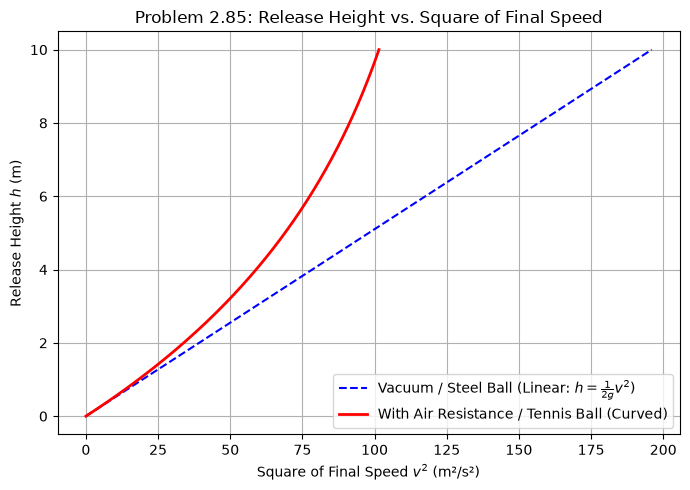

In [ ]:
# Height range
h_arr = np.linspace(0, 10, 200)

# Ideal case (No drag): v_sq = 2*g*h
g_num = 9.80
v2_ideal = 2 * g_num * h_arr

# Qualitative Drag model: Quadratic drag reduces v^2 progressively at higher h
v2_drag = (2 * g_num / 0.15) * (1 - np.exp(-0.15 * h_arr))

plt.figure(figsize=(7, 5))
plt.plot(
    v2_ideal,
    h_arr,
    "b--",
    label="Vacuum / Steel Ball (Linear: $h = \\frac{1}{2g} v^2$)",
)
plt.plot(v2_drag, h_arr, "r-", lw=2, label="With Air Resistance / Tennis Ball (Curved)")

plt.xlabel("Square of Final Speed $v^2$ (m²/s²)")
plt.ylabel("Release Height $h$ (m)")
plt.title("Problem 2.85: Release Height vs. Square of Final Speed")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()